In [55]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import Literal

## Lib for Agent
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import create_agent
from langchain.tools import tool

C:\Users\91910\AppData\Local\Temp\ipykernel_16048\374436077.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import GoogleSerperAPIWrapper


In [57]:
## State

class FlowState(BaseModel):
    question:str = Field(description="user passed question")
    category:Literal["coading", "google_search", "weather"] = Field(default="google_search")
    answer:str = Field(default="")

In [58]:
## 2 State for structured output

class QuestionCategory(BaseModel):
    category : Literal["coading", "google_search", "weather"] = Field(default="google_search", description= "Question Category")


In [59]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [61]:
### Define you agent , google agent, weather agent

search = GoogleSerperAPIWrapper()
tools = [search.run]


google_agent = create_agent(
    model = llm,
    tools=tools,
    system_prompt="You are an agent and can search any question on google."
)

## Weather Agent

@tool
def get_weather(city:str):
    """It provide real time weather details for any city """
    return f"The current temperature in {city} is 23.C"

weather_agent = create_agent(
    model = llm,
    tools=[get_weather],
    system_prompt="You are an agent and can provide real time weather details ."
)

In [ ]:
def check_question_category(state:FlowState) -> FlowState:
    st_llm = llm.with_structured_output(QuestionCategory)
    res = st_llm.invoke(f"I want to know the category of my question, question is : {state.question}. if you are not sure then just give 'google_search' as a category")
    state.category = res.category
    return state

In [ ]:
# flow = FlowState(question =  "What is address of taj mahal ?")
# check_question_category(flow)

In [ ]:
def route(state:FlowState) -> Literal["coading", "google_search", "weather"]:
    return state.category

In [ ]:
def coading_node(state:FlowState) -> FlowState:
    print("Coading NODE...")
    res = llm.invoke(f"You are a coading expert: {state.question}")
    state.answer = res.Content 
    return state   


def google_search_node(state:FlowState) -> FlowState:
    res = google_agent.invoke({"messages":[{
        "role":"user", "content": state.question
    }]})
    state.answer = res["messages"][-1].content
    return state            


def weather_node(state:FlowState) -> FlowState:
    res = weather_agent.invoke({"messages":[{
            "role":"user", "content": state.question
    }]})
    state.answer = res["messages"][-1].content
    return state 

In [ ]:
graph = StateGraph(FlowState)

graph.add_node("check_question_category", check_question_category)
graph.add_node("coading", coading_node )
graph.add_node("weather", weather_node)
graph.add_node("google_search", google_search_node)


graph.add_edge(START, "check_question_category")
graph.add_conditional_edges("check_question_category", route)
graph.add_edge("coading", END)
graph.add_edge("google_search", END)
graph.add_edge("weather", END)

graph = graph.compile()


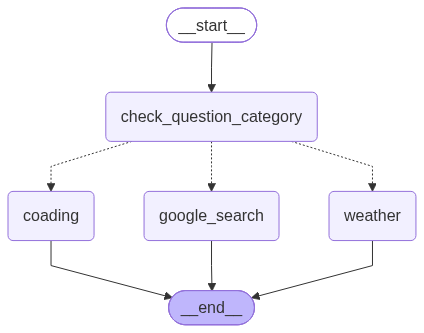

In [64]:
from IPython.display import Image

Image(graph.get_graph().draw_mermaid_png())


In [73]:
response = graph.invoke({"question":"What is temperature in Bhopal ?"})

In [74]:
response

{'question': 'What is temperature in Bhopal ?',
 'category': 'weather',
 'answer': 'The current temperature in Bhopal is 23 degrees Celsius.'}